# 🏦 Projeto de Previsão de Churn Bancário

## 1. Visão Geral do Projeto
Bem-vindo a este projeto de competição do Kaggle focado na retenção de clientes. O objetivo principal deste estudo é desenvolver um modelo de **Machine Learning** capaz de prever clientes que têm alta probabilidade de realizar o *churn*.

No contexto de negócios, **Churn** refere-se ao evento em que um cliente decide deixar de usar um serviço ou cancelar uma assinatura. Neste conjunto de dados específico, estamos lidando com clientes de uma instituição financeira.

## 2. Contexto e Importância
A previsão de evasão de clientes é vital para empresas de diversos setores, especialmente telecomunicações e serviços bancários. A perda de um cliente não resulta apenas em perda imediata de receita, mas afeta a lucratividade a longo prazo.

**Por que isso é crítico?**

* **Custo de Aquisição:** Adquirir um novo cliente pode ser de **5 a 25 vezes mais caro** do que reter um cliente existente.
* **Estratégia:** Compreender os fatores que levam ao cancelamento permite que a empresa implemente estratégias de retenção direcionadas e proativas antes que o cliente saia.

## 3. Sobre os Dados
O conjunto de dados fornece atributos variados dos clientes, incluindo informações demográficas, detalhes da conta e comportamentos transacionais. O objetivo é utilizar essas características para prever a variável alvo (`Exited`).

### Dicionário de Dados

| Variável | Descrição |
| :--- | :--- |
| **CustomerId** | Identificador único para cada cliente. |
| **Surname** | Sobrenome do cliente (geralmente irrelevante para a modelagem, usado para identificação). |
| **CreditScore** | Pontuação numérica que representa a solvência/risco de crédito do cliente. |
| **Geography** | O país de residência do cliente (ex: França, Alemanha, Espanha). |
| **Gender** | O gênero do cliente (Masculino ou Feminino). |
| **Age** | A idade do cliente. |
| **Tenure** | Número de anos que o cliente está no banco. |
| **Balance** | O saldo atual na conta do cliente. |
| **NumOfProducts** | Número de produtos que o cliente possui no banco. |
| **HasCrCard** | Indica se o cliente possui cartão de crédito (1 = Sim, 0 = Não). |
| **IsActiveMember** | Indica se o cliente é um membro ativo (1 = Sim, 0 = Não). |
| **EstimatedSalary** | O salário anual estimado do cliente. |
| **Exited** | **Variável Alvo.** Indica se o cliente deu churn (1 = Sim, 0 = Não). |


## 4. Objetivo
Construir um modelo preditivo que analise esses atributos e identifique padrões ocultos que sinalizem por que um cliente decide deixar o banco, permitindo uma classificação precisa da probabilidade de saída.

## 📥 Importar e Carregar Datasets

### Importar Bibliotecas

In [ ]:
# Carregar e analisar dados
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from typing import Union, Dict, List

# Pré-Processamento de Dados
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# Treino e Avaliação dos modelos
import scipy.stats as st
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import joblib

In [ ]:
# Importar biblioteca
import kaggle
competicao = 'churn-competition-pdc'

print(f"Baixando os dados da competição: {competicao}...")
kaggle.api.competition_download_cli(competicao)

arquivo_zip = f"{competicao}.zip"

if os.path.exists(arquivo_zip):
    print("Descompactando os arquivos...")
    with zipfile.ZipFile(arquivo_zip, 'r') as zip_ref:
        zip_ref.extractall() 
    
    os.remove(arquivo_zip)
    print("Processo concluído com sucesso!")
else:
    print(f"Erro: O arquivo {arquivo_zip} não foi encontrado.")

Baixando os dados da competição: churn-competition-pdc...


100%|██████████| 636k/636k [00:00<00:00, 778kB/s]


Descompactando os arquivos...
Processo concluído com sucesso!


## 🔍 Análise Exploratória de Dados (EDA)

### Exploração Inicial

In [10]:
# Carregar dados com pandas
df_treino = pd.read_csv( 'train.csv')
df_treino.head(2)

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15642345.0,Ikedinachukwu,659.0,France,Male,42.0,7.0,0.0,2.0,1.0,0.0,184843.77,0.0
1,1,15765311.0,Zikoranachidimma,749.0,France,Male,29.0,9.0,0.0,2.0,1.0,0.0,162960.05,0.0


In [13]:
# Visaulizar informações
df_treino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [ ]:
# Visualizar colunas
df_treino.columns

Index(['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [ ]:
# Separar atributos numericos e categoricos
df_cat = df_treino.select_dtypes(include='object').drop(columns='Surname')
df_num = df_treino.select_dtypes(exclude='object').drop( columns= ['id', 'CustomerId'])

col_cat = df_cat.columns
col_continuas = [ 'CreditScore', 'Age', 'Balance', 'EstimatedSalary' ]
col_discretas = df_num.drop(columns= col_continuas, axis=1 )

### Exploração das variáveis continuas

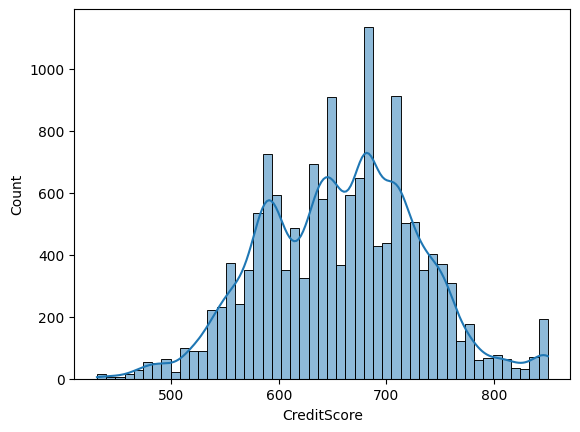

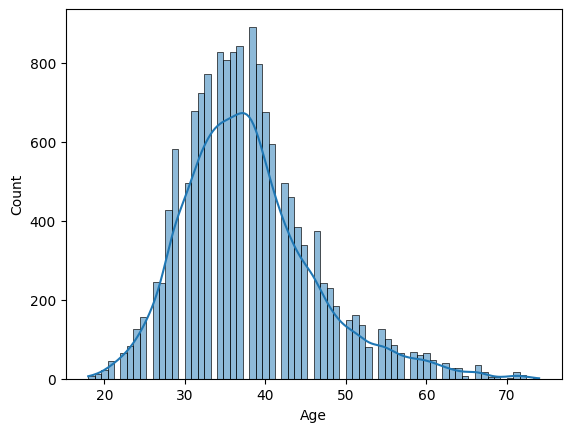

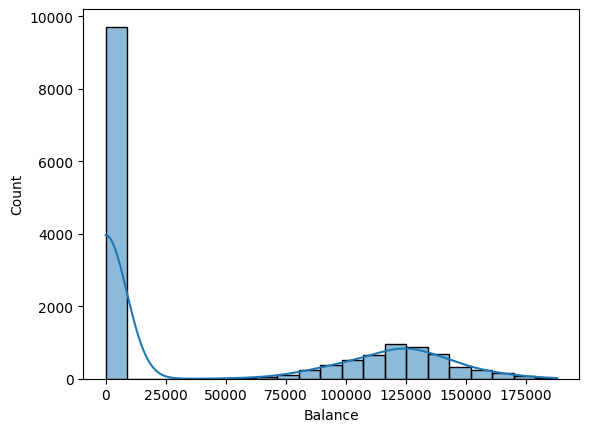

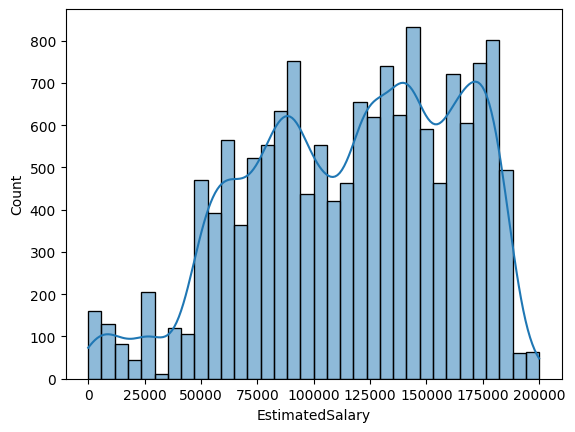

In [16]:
for coluna in col_continuas:
  if coluna != 'Exited':
    sns.histplot(x= df_num[coluna], kde= True)
    plt.show()

### Exploração Variáveis Categóricas e Discretas


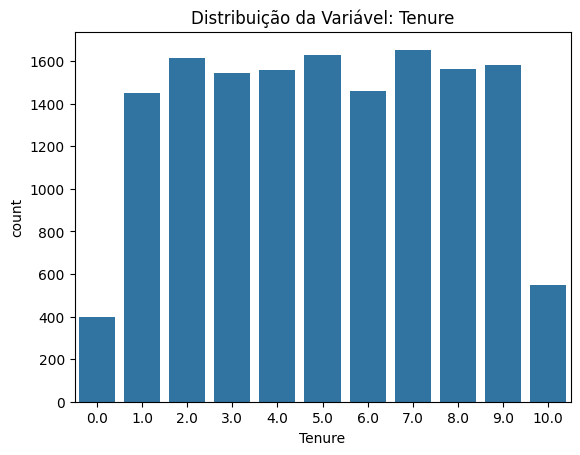

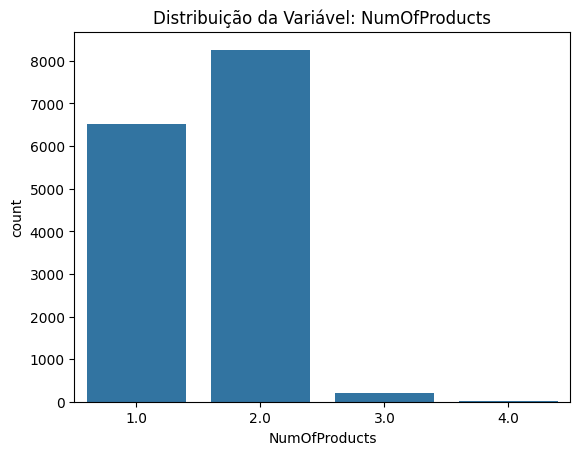

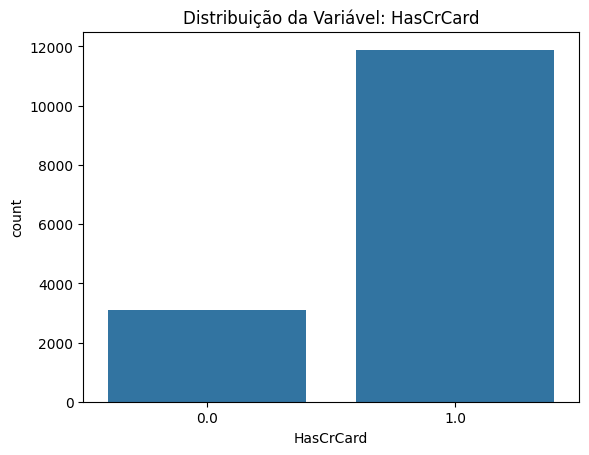

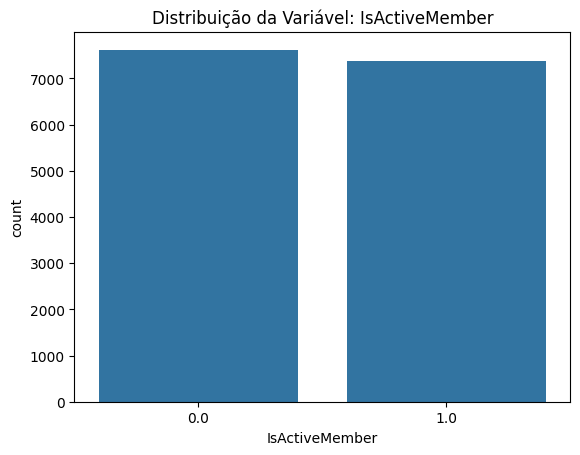

In [17]:
for coluna in col_discretas:
  if coluna != 'Exited':
    sns.countplot( x= df_num[coluna])
    plt.title(f'Distribuição da Variável: {coluna}')
    plt.show()

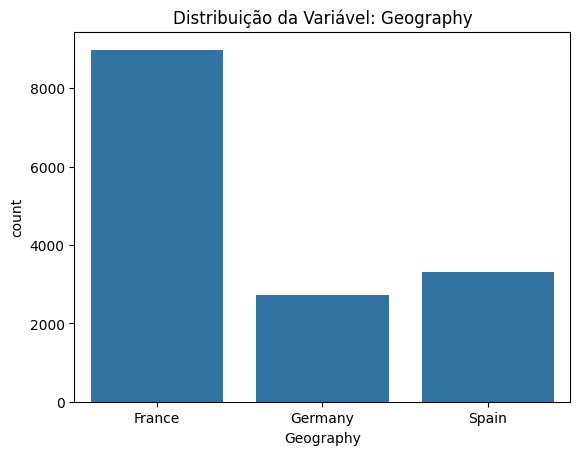

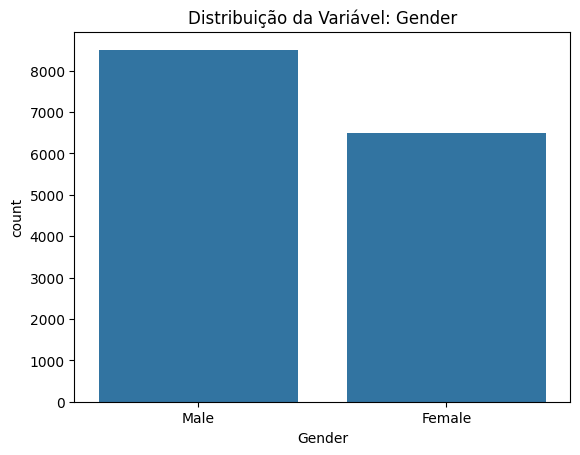

In [18]:
for coluna in col_cat:
  sns.countplot( x= df_cat[coluna])
  plt.title(f'Distribuição da Variável: {coluna}')
  plt.show()

### Exploração Variável alvo

In [19]:
(df_num['Exited'].value_counts(normalize= True) * 100).round(2)
# Possui 20% de clientes que cancelaram o pedido

Exited
0.0    79.36
1.0    20.64
Name: proportion, dtype: float64

C:\Users\kayky\AppData\Local\Temp\ipykernel_19172\1444441331.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot( data= df_num, x= 'Exited', palette='deep')


<Axes: xlabel='Exited', ylabel='count'>

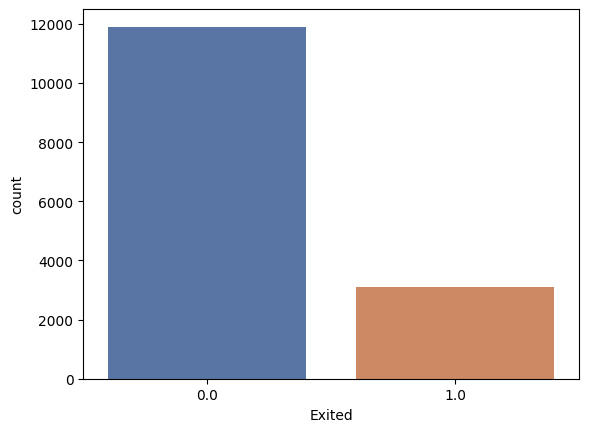

In [20]:
sns.countplot( data= df_num, x= 'Exited', palette='deep')

### Análise da relação entre as variáveis

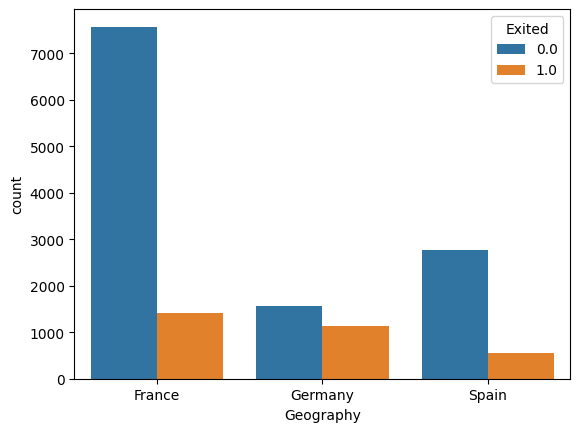

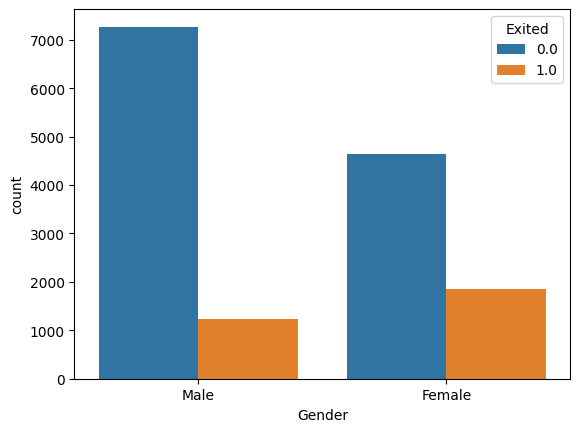

In [21]:
for coluna in col_cat:
  sns.countplot( data= df_cat, x= coluna, hue=df_num['Exited'] )
  plt.show()

In [ ]:
# Proporção de cancelamento de mulheres
(df_treino.loc[df_cat['Gender'] == 'Female']['Exited'].value_counts( normalize= True) * 100).round(2)

,proportion
Exited,
0.0,71.37
1.0,28.63


In [ ]:
# Proporção de cancelamneto entre alemães
(df_treino.loc[df_cat['Geography'] == 'Germany']['Exited'].value_counts( normalize= True) * 100).round(2)

,proportion
Exited,
0.0,57.86
1.0,42.14


In [ ]:
# Maior parte dos cancelamentos são mulheres
# 30% entre mulhes cancelaram
# 40% entre alemãos cancelaram o serviço
# Apesar de mais cancelamentos de franceses, ocorre mais cancelamentos proporcionalmente entre alemãos

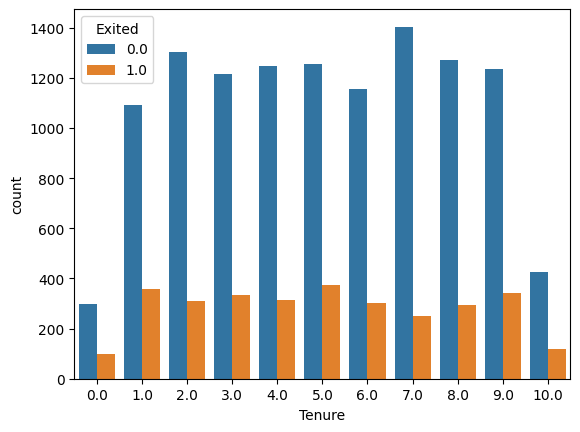

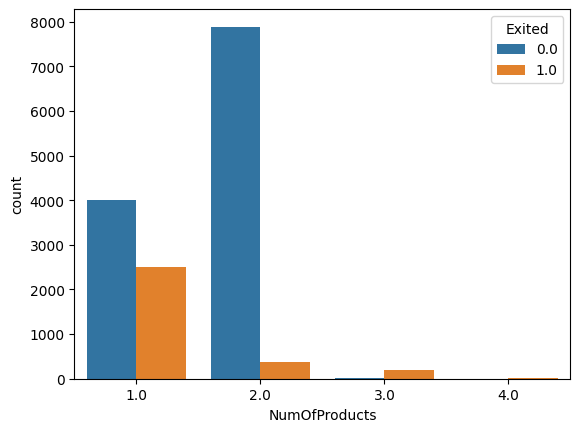

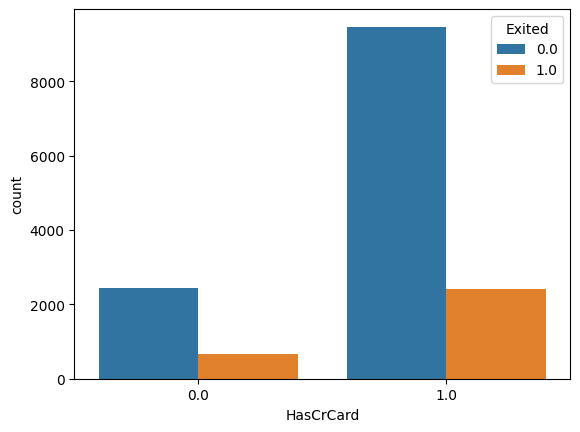

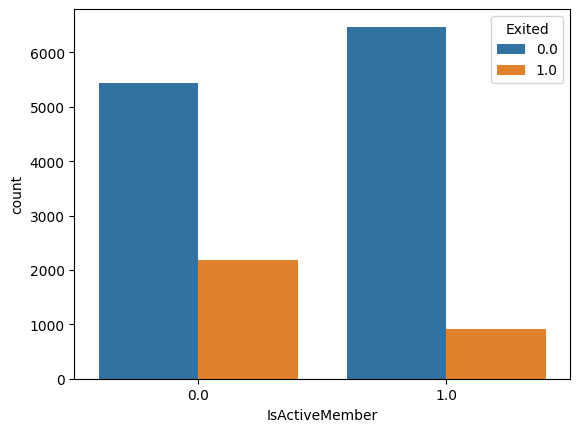

In [ ]:
for coluna in col_discretas:
  if coluna != 'Exited':
    sns.countplot( data= df_num, x= coluna, hue= 'Exited')
    plt.show()

In [ ]:
# Porcentagem de cancelamentos de pessoas que adquiram um único produto no banco
(df_num.loc[df_num['NumOfProducts'] == 1]['Exited'].value_counts( normalize= True) * 100).round(2)

,proportion
Exited,
0.0,61.52
1.0,38.48


In [ ]:
# Porcentagem de cancelamentos de pessoas que não são memnbros ativos do banco
(df_num.loc[df_num['IsActiveMember'] == 0]['Exited'].value_counts( normalize= True) * 100).round(2)

,proportion
Exited,
0.0,71.3
1.0,28.7


In [ ]:
# Em 60% dos clientes que compraram um único produto ocorreu churn
# Em 30% dos clientes que não são membros ativos ocorreu churn

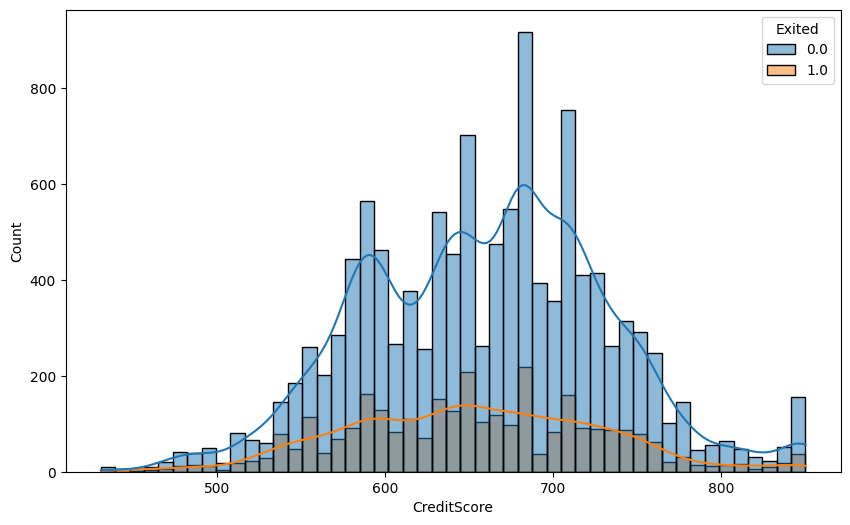

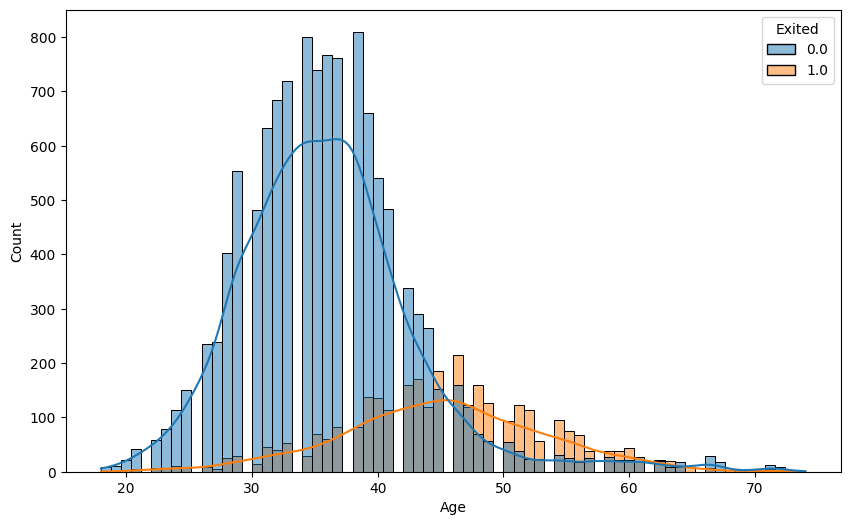

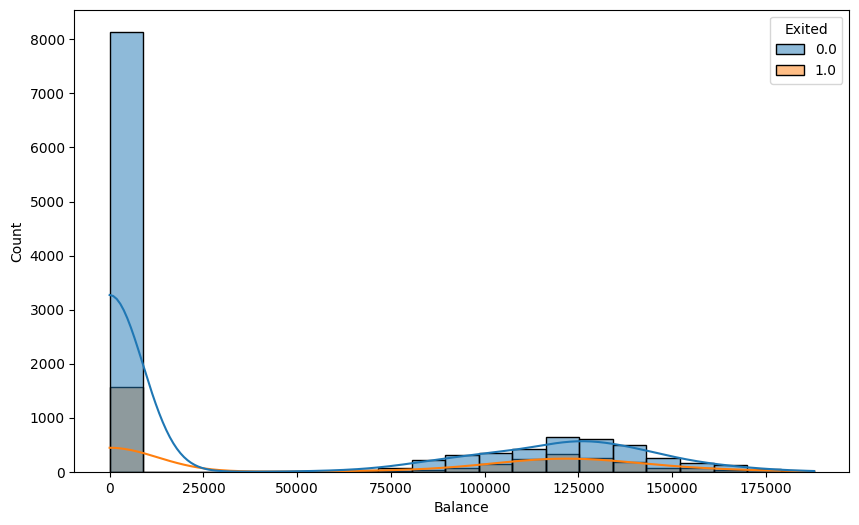

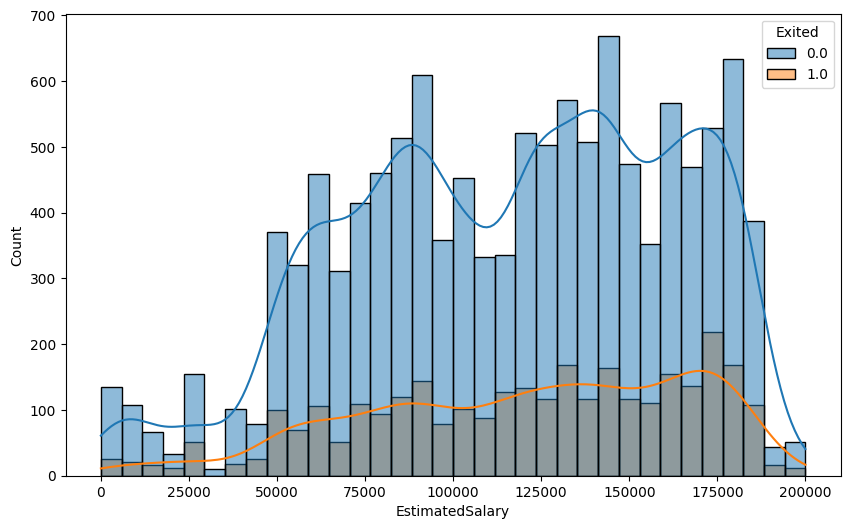

In [ ]:
for coluna in col_continuas:
  plt.figure(figsize=(10, 6))
  sns.histplot(
      data=df_treino,
      x=coluna,
      hue='Exited',
      kde=True,
  )
  plt.show()

In [ ]:
# Porcentagem de cancelamento de pessoas com mais de 45 anos
(df_num.loc[(df_num['Age'] > 45)]['Exited'].value_counts( normalize= True)) * 100

,proportion
Exited,
1.0,63.39814
0.0,36.60186


In [86]:
# Ocorre um aumento de cancelamentos na faixa etária entre 45 a 60 anos

<Axes: >

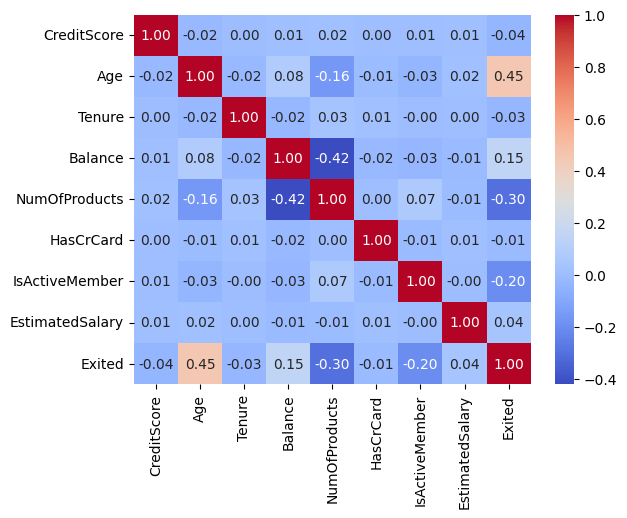

In [ ]:
# Construir matriz de correlação entre as variáveis
matrix_cor = df_num.corr()
sns.heatmap(data= matrix_cor, annot=True, cmap='coolwarm', fmt='.2f')

In [ ]:
# A correlação expressiva entre as variáveis de idade, numero de produtos e se é um membro ativo com o cancelamento pode ser verificado na matrix de correlação

# 📊 Consolidação de Insights: Análise Exploratória de Dados (EDA)

Após a análise inicial das variáveis e suas relações com a variável alvo (`Exited`), destacam-se os seguintes padrões de comportamento e riscos:

### 1. Visão Geral do Churn
* **Taxa Global:** A base de dados apresenta uma taxa de cancelamento de **20%**. Isso indica um desbalanceamento de classes que deve ser considerado na etapa de modelagem (possível necessidade de balanceamento/oversampling).

### 2. Perfil Demográfico (Gênero e Geografia)
* **Gênero:**
    * A **maior parte absoluta** dos cancelamentos provém do público feminino.
    * Proporcionalmente, **30% das mulheres** cancelaram o serviço, indicando um risco maior neste grupo comparado aos homens.
* **Geografia:**
    * A **França** lidera em números absolutos de cancelamentos (devido ao maior volume de clientes).
    * Entretanto, a **Alemanha** é a região mais crítica proporcionalmente: **40% dos clientes alemães** cancelaram o serviço.

### 3. Comportamento e Produtos
* **Produtos Contratados:** Clientes com apenas **um único produto** apresentam altíssimo risco, com uma taxa de churn de **60%** neste grupo.
* **Engajamento:** A inatividade é um forte sinal de alerta. Entre os clientes identificados como **não ativos**, **30%** deixaram o banco.

### 4. Correlações e Variáveis Chave
Através da **Matriz de Correlação**, confirmamos estatisticamente que as variáveis com maior influência linear sobre o cancelamento são:
* **Idade** (Age)
* **Número de Produtos** (NumOfProducts)
* **Membro Ativo** (IsActiveMember)

---
> **Conclusão da Etapa:** O perfil de maior risco identificado até o momento é composto por **mulheres**, residentes na **Alemanha**, com **baixa atividade** e, frequentemente, detentoras de apenas **um produto**.

## 🛠️ Pré Processamento de Dados

###  Engenharia de Dados e Pipeline de Pré-processamento

Para garantir que os modelos capturem os padrões mais complexos de *churn*, estruturamos uma pipeline automatizada que lida com a limpeza, criação de novas variáveis e normalização dos dados.

#### 1. Limpeza e Remoção de Ruído (`Transformador_remocao_atributos`)
Removemos as colunas `id`, `CustomerId` e `Surname`.

* **Justificativa:** Atributos de identificação possuem altíssima cardinalidade e não carregam poder preditivo. Mantê-los poderia induzir o modelo ao *overfitting*, fazendo-o "decorar" nomes ou IDs em vez de aprender padrões comportamentais reais.

#### 2. Engenharia de Atributos (`Combinar_atributos`)
A criação de novas variáveis (*Feature Engineering*) permite que o modelo enxergue relações entre os dados que não estão explícitas originalmente. Criamos cinco novas métricas:

* **`balance_salary_ratio` (Saldo / Salário):** Indica o nível de riqueza acumulada em relação à renda mensal. Um cliente com saldo alto mas salário baixo pode ter um perfil de investimento diferente de alguém com salário alto e saldo baixo.
* **`tenure_age_ratio` (Tempo de Casa / Idade):** Mede a fidelidade proporcional à vida do cliente. Um cliente jovem com 5 anos de casa é, proporcionalmente, mais fiel do que um cliente idoso com os mesmos 5 anos.
* **`credit_age_ratio` (Score de Crédito / Idade):** Ajuda a entender a saúde financeira em relação à etapa de vida do cliente.
* **`active_product_score` (Membro Ativo × Nº de Produtos):** Esta variável potencializa o fator de engajamento. Clientes que possuem muitos produtos e são ativos recebem uma pontuação maior, sendo o grupo com maior barreira de saída (menor risco de *churn*).
* **`balance_per_product` (Saldo / Nº de Produtos):** Identifica a concentração de recursos por produto contratado.

#### 3. Pipeline Numérica (`pipeline_num`)
* **Tratamento:** Após a criação das novas variáveis, aplicamos o `StandardScaler`.
* **Justificativa:** Modelos como **SVM (SVC)** e **KNN** baseiam-se em cálculos de distância geométrica. Se não padronizarmos as variáveis (deixando-as com média 0 e desvio padrão 1), atributos com valores altos (como `Balance`) dominariam completamente o modelo, tornando variáveis de escala menor (como `NumOfProducts`) irrelevantes.

#### 4. Pipeline Categorical (`pipeline_cat`)
* **Tratamento:** Utilizamos o `OneHotEncoder` para as variáveis geográficas e de gênero.
* **Justificativa:** Algoritmos de Machine Learning operam apenas com números. A codificação *One-Hot* transforma categorias (ex: França, Alemanha, Espanha) em colunas binárias (0 ou 1), permitindo que o modelo entenda as diferenças entre regiões sem atribuir uma ordem matemática arbitrária entre elas.

#### 5. Transformador de Colunas (`ColumnTransformer`)
O uso do `ColumnTransformer` é a peça final que une as duas frentes. Ele garante que as transformações certas sejam aplicadas às colunas certas de forma atômica, evitando o vazamento de dados (*data leakage*) e facilitando o *deploy* do modelo, pois qualquer dado novo passará exatamente pelo mesmo processo de fabricação.

In [ ]:
# Separar variáveis preditoras e predição
X_treino = df_treino.drop(columns='Exited', axis=1)
y_treino = df_treino['Exited'].astype(int).copy()

In [12]:
# Codificar um transformador para remover atributos
class Transformador_remocao_atributos(BaseEstimator, TransformerMixin):
    def __init__(self, atributos_remover= []):
        self.atributos_remover = atributos_remover
    def fit(self,X,y=None):
        return self
    def transform(self,X,y=None):
        return X.drop(columns=self.atributos_remover,axis=1)
    def get_feature_names_out(self, input_features=None):
        # Converter para pnadas
        original_features = pd.Index(input_features)

        # realizar filtro
        remaining_features = original_features.drop(self.atributos_remover, errors='ignore')

In [ ]:
# Codificar um transformador para criar atributos novos
class Combinar_atributos(BaseEstimator, TransformerMixin):
    def __init__(self, colunas=None):
        self.colunas = colunas

    def fit(self, X, y=None):
        if hasattr(X, 'columns'):
            self.col_names_ = X.columns.tolist()
        else:
            self.col_names_ = self.colunas

        self.idx_ = {name: i for i, name in enumerate(self.col_names_)}
        return self

    def transform(self, X, y=None):
        X_array = np.array(X)
        balance = X_array[:, self.idx_['Balance']]
        salary = X_array[:, self.idx_['EstimatedSalary']]
        tenure = X_array[:, self.idx_['Tenure']]
        age = X_array[:, self.idx_['Age']]
        credit = X_array[:, self.idx_['CreditScore']]
        active = X_array[:, self.idx_['IsActiveMember']]
        products = X_array[:, self.idx_['NumOfProducts']]

        balance_salary_ratio = balance / (salary + 1e-6)
        tenure_age_ratio = tenure / (age + 1e-6)
        credit_age_ratio = credit / (age + 1e-6)
        active_product_score = active * products
        balance_per_product = balance / (products + 0.1)

        return np.c_[X_array,
                     balance_salary_ratio,
                     tenure_age_ratio,
                     credit_age_ratio,
                     active_product_score,
                     balance_per_product]

    def get_feature_names_out(self, input_features=None):
        if self.colunas is None and input_features is not None:
            original_features = list(input_features)
        elif self.colunas is not None:
            original_features = list(self.colunas)

        new_features = [
            "balance_salary_ratio",
            "tenure_age_ratio",
            "credit_age_ratio",
            "active_product_score",
            "balance_per_product",
        ]
        return original_features + new_features

In [ ]:
# Construir pipeline de pré processamento
features_cat = X_treino.select_dtypes(include='object').columns
features_num = X_treino.select_dtypes(exclude='object').columns

colunas_que_chegam_no_combinador = features_num.drop(['CustomerId', 'id'])

pipeline_num = Pipeline(
    [
        ('dropper_num', Transformador_remocao_atributos(atributos_remover=['CustomerId', 'id'])),
        ('combinar_atrbb', Combinar_atributos(colunas=colunas_que_chegam_no_combinador)),
        ('scaler', StandardScaler())
    ]
)

pipeline_cat = Pipeline(
    [
        ('dropper_cat', Transformador_remocao_atributos(atributos_remover=['Surname'])),
        ('one_hot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

pipeline = ColumnTransformer(
    [
        ('col_num', pipeline_num, features_num),
        ('col_cat', pipeline_cat, features_cat)
    ]
)

In [ ]:
# Executar pipeline
X_transformado = pipeline.fit_transform(X_treino)

## 🏘️ Modelo K-Nearest Neighbors(KNN)

O **K-Nearest Neighbors (KNN)** é um algoritmo de aprendizado de máquina simples e intuitivo, baseado no princípio da **proximidade**. A intuição central do modelo é: dados com características semelhantes tendem a pertencer à mesma classe (no nosso caso, Churn ou Não Churn). 

**Como ele toma a decisão?**
1. **Definição de *K*:** Escolhemos um número de vizinhos ($K$) que o algoritmo vai consultar.
2. **Cálculo de Distância:** Quando apresentamos um novo cliente, o modelo calcula a distância geométrica (geralmente a Distância Euclidiana) entre esse cliente e todos os clientes da base de treino.
3. **Votação:** O modelo seleciona os $K$ clientes mais próximos e faz uma "votação". A classe majoritária entre esses vizinhos será a previsão final para o novo cliente.


### 📊 Treino e Avaliação do Modelo

Para garantir uma comparação justa e estatisticamente sólida entre os diferentes algoritmos de Machine Learning, centralizamos o processo de teste na função `avaliacao_perfomace`. Esta função automatiza quatro etapas críticas de avaliação:

#### 1. Treinamento Automatizado
A função inicia realizando o `fit` do modelo fornecido utilizando o conjunto de dados transformado (`X_transformado`). Isso garante que o modelo aprenda os padrões de *churn* antes de ser testado.

#### 2. Validação Cruzada e Intervalo de Confiança
Em vez de uma única medição de acurácia, utilizamos a **Validação Cruzada (Cross-Validation)** com 5 dobras (*cv=5*). 
* **Acurácia Média:** Representa o desempenho esperado do modelo em dados não vistos.
* **Intervalo de Confiança (95%):** Calculamos um intervalo estatístico (usando a distribuição t de Student) que nos indica a confiabilidade da acurácia. Um intervalo estreito sugere que o modelo é estável e não depende de um "sorteio de sorte" nos dados de treino.



#### 3. Relatório de Classificação (`classification_report`)
Como a acurácia pode ser enganosa em bases desbalanceadas, a função gera as métricas de **Precisão**, **Recall** (Sensibilidade) e **F1-Score**. 
* Para o nosso negócio, o foco principal é o **Recall da Classe 1**, que mede a nossa eficácia em capturar clientes que realmente pretendem sair do banco.

#### 4. Matriz de Confusão Visual
A função encerra gerando um mapa de calor (*Heatmap*) da Matriz de Confusão. Esta visualização é essencial para identificarmos rapidamente:
* **Verdadeiros Positivos:** Clientes em risco identificados corretamente.
* **Falsos Negativos:** Clientes em risco que o modelo deixou passar (o custo mais alto para o banco).
* **Falsos Positivos:** Clientes estáveis que o modelo marcou erroneamente como risco.

---
💡 **Observação:** O uso de `cross_val_predict` dentro da função assegura que as métricas de cada cliente sejam geradas de forma "limpa", ou seja, a previsão de cada dado é feita por um modelo que nunca viu aquele dado específico durante o treinamento.

In [ ]:
# Vamos definir uma função de treinamento e avaliação da perfomace do modelo
def avaliacao_perfomace( nome_modelo :str, modelo : BaseEstimator, X_transformado, y_treino ) -> None:
  # Treinar modelo
  modelo.fit( X_transformado, y_treino )

  # Avaliar acuracia do modelo
  val_cruzada = cross_val_score( modelo, X_transformado, y_treino, scoring= 'accuracy', cv= 5 )
  n = len( val_cruzada )
  media = val_cruzada.mean()
  desvio = st.sem( val_cruzada )
  i_c = st.t.interval( confidence = 0.95, df = n - 1, loc = media, scale = desvio )
  lim_inf = round( i_c[0], 3 )
  lim_sup = round( i_c[1], 3 )
  print(f"Acurácia média : { round(val_cruzada.mean(), 3) }, Intervalo de Confiança: [{lim_inf},{lim_sup}]\n")

  # Avaliar métricas de recall, precision e f1-score
  y_pred = cross_val_predict( modelo, X_transformado, y_treino, cv= 5)
  print(f"Relatório de métricas de {nome_modelo}:\n")
  print(classification_report( y_treino, y_pred ))

  # Avaliar matrix de confusão
  matrix_conf = confusion_matrix(y_treino, y_pred)
  sns.heatmap(matrix_conf, annot=True, fmt='d', cmap='Blues')
  plt.title(f'Matriz de Confusão de {nome_modelo}\n')
  plt.show()

In [28]:
# Instanciar Modelo
knn = KNeighborsClassifier( )

Acurácia média : 0.877, Intervalo de Confiança: [0.872,0.882]

Relatório de métricas de KNN:

              precision    recall  f1-score   support

           0       0.91      0.94      0.92     11904
           1       0.74      0.62      0.68      3096

    accuracy                           0.88     15000
   macro avg       0.82      0.78      0.80     15000
weighted avg       0.87      0.88      0.87     15000



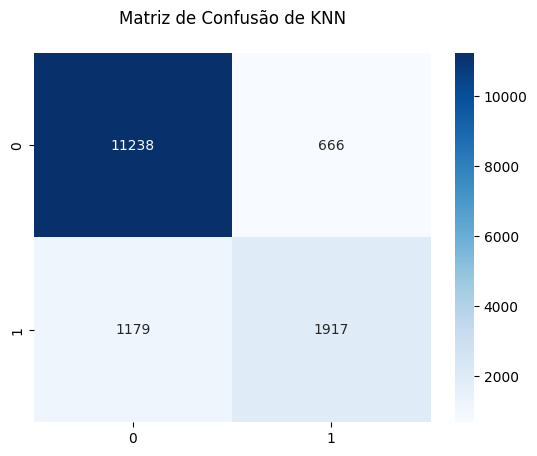

In [42]:
# Avaliar perfomace do modelo base
avaliacao_perfomace( "KNN", knn, X_transformado, y_treino )

### ⚙️ Seleção de Hiper-parâmetros

A função `tunagem` foi desenvolvida para automatizar o ciclo de vida dos modelos de Machine Learning neste projeto, unindo a busca pelos melhores hiperparâmetros com uma estratégia de **persistência de modelos** (Save/Load).

Esta abordagem garante eficiência e reprodutibilidade, operando através dos seguintes pilares:

#### 1. Persistência de Dados (Evitando Re-treinamento)
A função verifica se o arquivo do modelo já existe no diretório especificado (`caminho_modelo`). 
* **Se existir:** O modelo é carregado instantaneamente via `joblib`, economizando tempo computacional precioso.
* **Se não existir:** A função inicia o processo de treinamento do zero.

#### 2. Busca Exaustiva com `GridSearchCV`
Utilizamos a técnica de **Grid Search**, que testa sistematicamente todas as combinações possíveis de hiperparâmetros definidos no `param_grid`. 
* **Cálculo de Combinações:** A função calcula e exibe antecipadamente quantas variações do modelo serão testadas, permitindo prever a carga computacional.
* **Paralelismo:** O parâmetro `n_jobs=-1` instrui o computador a usar todos os núcleos de processamento disponíveis para acelerar a busca.



#### 3. Critério de Seleção: ROC AUC
Embora a nossa análise final foque no *Recall*, a busca pelos melhores parâmetros utiliza por padrão a métrica **ROC AUC** (`scoring_metric='roc_auc'`). 
* **Justificativa:** A curva ROC AUC avalia a capacidade do modelo de distinguir entre as classes (Churn vs. Não Churn) em diferentes limiares, garantindo um modelo equilibrado e robusto antes de refinarmos a análise para o custo dos falsos negativos.

#### 4. Integração com Avaliação de Performance
Uma vez encontrado o melhor conjunto de parâmetros (o `best_estimator_`), a função:
1. Salva o arquivo fisicamente no disco.
2. Exibe os parâmetros vencedores.
3. Chama automaticamente a função `avaliacao_perfomace`, gerando o relatório completo de métricas e a matriz de confusão para o melhor modelo encontrado.


In [ ]:
# Definir Função de tunagem de modelos
def tunagem(
    caminho_modelo: str,
    nome_modelo : str,
    modelo: BaseEstimator,
    X_treino: np.ndarray,
    y_treino: np.ndarray,
    param_grid: Union[Dict, List[Dict]] = None,
    scoring_metric: str = 'roc_auc',
    cv_folds: int = 5
) -> BaseEstimator:

    if not os.path.exists(caminho_modelo):
        n_combinacoes = 0
        if isinstance(param_grid, dict):
            comb = 1
            for v in param_grid.values():
                comb *= len(v)
            n_combinacoes = comb
        elif isinstance(param_grid, list):
            for grid in param_grid:
                comb = 1
                for v in grid.values():
                    comb *= len(v)
                n_combinacoes += comb

        print(f"Modelo não encontrado. Iniciando GRID SEARCH ({n_combinacoes} combinações)")

        grid_search = GridSearchCV(
            estimator=modelo,
            param_grid=param_grid,
            scoring=scoring_metric,
            cv=cv_folds,
            n_jobs=-1,
            verbose=3,
            error_score='raise'
        )

        grid_search.fit(X_treino, y_treino)

        diretorio = os.path.dirname(caminho_modelo)
        if diretorio:
            os.makedirs(diretorio, exist_ok=True)

        joblib.dump(grid_search.best_estimator_, caminho_modelo)
        print("Busca Finalizada!")

        # Resultados
        print("\nMelhores parâmetros encontrados:")
        print(grid_search.best_params_)
        print("\nPerformance Média do Melhor estimador:\n")

        avaliacao_perfomace( nome_modelo, grid_search.best_estimator_ , X_treino, y_treino)

        return grid_search.best_estimator_

    else:
        print("Modelo encontrado! Carregando...")
        return joblib.load(caminho_modelo)

Vamos construir um grid de hiperparâmetros para otimizar o nosso modelo KNN. Para evitar que o algoritmo teste combinações matematicamente inválidas e economizar tempo de processamento, dividimos nossa grade em dois dicionários distintos:

#### 1. Primeiro Grid: O Espaço de Minkowski
Este primeiro bloco foca exclusivamente na métrica `minkowski` e suas variações geométricas.

* **`n_neighbors` [3, 5, 7, 9, 11, 15, 21]:** Definimos a quantidade de vizinhos a serem consultados. Utilizamos apenas números ímpares para evitar "empates" na votação em nosso problema de classificação binária (Churn vs. Não Churn). O range varia de valores pequenos (que capturam padrões muito específicos, mas têm risco de overfitting) a valores maiores (que suavizam a fronteira de decisão).
* **`weights` ['uniform', 'distance']:** Testa duas abordagens de votação. Em `uniform`, todos os vizinhos têm o mesmo peso na decisão. Em `distance`, os vizinhos mais próximos do cliente analisado ganham maior peso, o que pode ajudar a capturar fronteiras mais complexas de retenção ou evasão.
* **`metric` ['minkowski'] e `p` [1, 2, 3]:** A distância de Minkowski é uma generalização. O parâmetro `p` define exatamente como ela se comporta:
    * `p=1`: Equivale à Distância de Manhattan (soma das diferenças absolutas).
    * `p=2`: Equivale à Distância Euclidiana (a clássica linha reta entre dois pontos).
    * `p=3`: Explora distâncias de ordem superior.

#### 2. Segundo Grid: Métricas de Distância Alternativas
Este segundo bloco avalia métricas que analisam a proximidade dos dados sob lógicas diferentes da distância puramente espacial.

* **Por que separar?** Métricas como `cosine` e `chebyshev` não utilizam o parâmetro `p`. Se colocássemos todas as métricas em um único dicionário com a lista de valores de `p`, o Grid Search perderia muito tempo de processamento tentando cruzar `metric='cosine'` com `p=2` (o que geraria um erro ou seria ignorado). Separando os grids, garantimos que o processamento seja 100% focado em combinações úteis.
* **`metric` ['cosine', 'chebyshev']:**
    * `cosine` (Distância do Cosseno): Analisa o ângulo entre os pontos de dados, ignorando a magnitude. É excelente se quisermos identificar padrões de comportamento onde a proporção de uso dos serviços importa mais do que os valores absolutos.
    * `chebyshev`: Foca na maior diferença absoluta em uma única dimensão.

Modelo não encontrado. Iniciando GRID SEARCH (70 combinações)
Fitting 5 folds for each of 70 candidates, totalling 350 fits
Busca Finalizada!

Melhores parâmetros encontrados:
{'metric': 'minkowski', 'n_neighbors': 21, 'p': 1, 'weights': 'distance'}

Performance Média do Melhor estimador:

Acurácia média : 0.883, Intervalo de Confiança: [0.875,0.892]

Relatório de métricas de KNN:

              precision    recall  f1-score   support

           0       0.90      0.96      0.93     11904
           1       0.78      0.60      0.68      3096

    accuracy                           0.88     15000
   macro avg       0.84      0.78      0.80     15000
weighted avg       0.88      0.88      0.88     15000



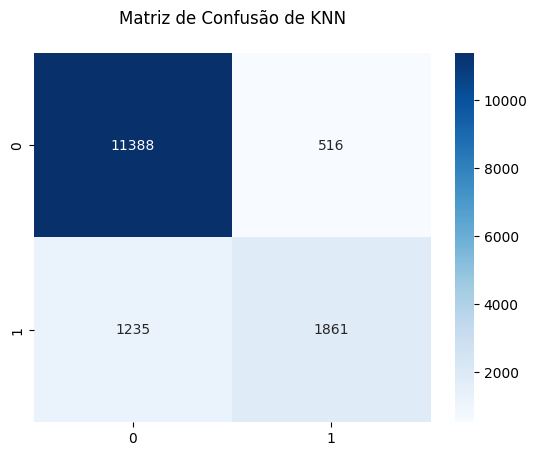

In [ ]:
# Definir hiperparâmetros para tunagem
param_grid_knn = [
    {
        'n_neighbors': [3, 5, 7, 9, 11, 15, 21], 
        'weights': ['uniform', 'distance'],
        'metric': ['minkowski'],
        'p': [1, 2, 3] 
    },
    
    # 2. Outras métricas de distância
    # O parâmetro 'p' é ignorado aqui, então separamos para não testar combinações inúteis.
    {
        'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
        'weights': ['uniform', 'distance'],
        'metric': ['cosine', 'chebyshev']
    }
]

caminho_modelo = 'modelo_knn.pkl'
best_knn = tunagem(caminho_modelo, "KNN", knn, X_transformado, y_treino, param_grid_knn)

## Regressão Logistica

Apesar de carregar a palavra "regressão" no nome, a **Regressão Logística** é um dos algoritmos estatísticos mais tradicionais e amplamente utilizados para problemas de **classificação binária** — exatamente o nosso cenário de prever Churn (1) ou Não Churn (0).

**Como o algoritmo funciona?**
1. **Foco na Probabilidade:** Enquanto uma regressão linear tenta prever um valor contínuo absoluto (como o preço de um imóvel), a regressão logística tem o objetivo de prever a **probabilidade** de um evento ocorrer (um valor estritamente entre 0 e 1).
2. **A Curva Sigmoide:** O segredo matemático do modelo é a função Sigmoide (uma curva em formato de "S"). O algoritmo calcula uma combinação linear das características do cliente (saldo, número de produtos, etc.) e passa esse resultado pela função Sigmoide, que "espreme" o valor para garantir que ele caia no intervalo probabilístico de 0% a 100%.
3. **Decisão por Limiar (*Threshold*):** Uma vez que o modelo calcula, por exemplo, que a chance de um cliente sair é de 0.75 (75%), ele aplica uma linha de corte (por padrão, 0.5). Como 0.75 é maior que o limiar, o modelo classifica esse cliente como propenso ao Churn.


### 📊 Treino e Avaliação do Modelo


In [25]:
# Instanciar modelo
reg_log = LogisticRegression( class_weight= 'balanced' )

Acurácia média : 0.816, Intervalo de Confiança: [0.806,0.826]

Relatório de métricas de Reg Log:

              precision    recall  f1-score   support

           0       0.94      0.82      0.88     11904
           1       0.54      0.80      0.64      3096

    accuracy                           0.82     15000
   macro avg       0.74      0.81      0.76     15000
weighted avg       0.86      0.82      0.83     15000



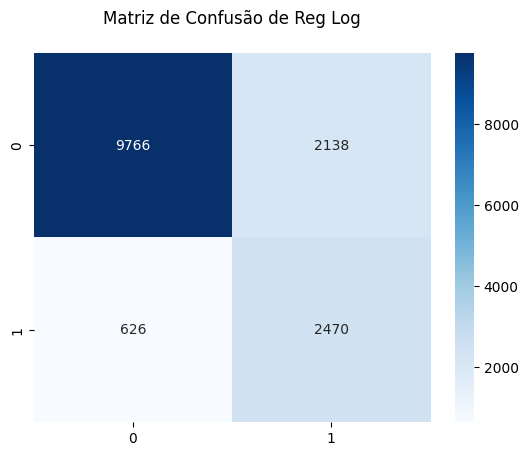

In [26]:
# Avaliar modelo base
avaliacao_perfomace( "Reg Log", reg_log, X_transformado, y_treino )

### ⚙️ Seleção de Hiper-parâmetros

Vamos construir um grid de hiperparâmetros para otimizar o nosso modelo de Regressão Logística. Dividimos a nossa malha de busca em dicionários distintos. O principal motivo aqui é a **compatibilidade técnica**: no Scikit-Learn, nem todo algoritmo de otimização matemática (`solver`) suporta todos os tipos de regularização (`penalty`). Separando os grids, garantimos um processamento sem erros e focado em combinações válidas.

Abaixo estão os detalhes de cada bloco testado para encontrar o melhor ajuste para prever o *churn*:

#### 1. Primeiro Grid: Penalidade L2 (Ridge)
A regularização L2 é o padrão da Regressão Logística. Ela é excelente para evitar *overfitting*, atuando na redução suave dos coeficientes das variáveis do nosso banco de dados, mas sem removê-las completamente.
* **`penalty` ['l2']:** Define a penalidade Ridge.
* **`C` [0.001, 0.01, 0.1, 1, 10, 100]:** É o inverso da força de regularização. Valores menores (ex: 0.001) aplicam uma regularização mais forte, simplificando o modelo. Valores maiores (ex: 100) dão mais liberdade ao modelo para se ajustar aos dados de treino.
* **`solver` ['lbfgs', 'newton-cg', 'sag']:** Algoritmos matemáticos otimizados que lidam muito bem com a penalidade L2.
* **`max_iter` [1000, 2500]:** Aumentamos o número máximo de iterações em relação ao padrão da biblioteca para garantir que os *solvers* tenham tempo suficiente para convergir matematicamente.

#### 2. Segundo Grid: Penalidade L1 (Lasso)
A regularização L1 tem uma propriedade fantástica: ela atua como um **seletor automático de variáveis**. Se uma coluna não tiver importância para prever o *churn*, o modelo "zera" o peso dessa coluna.
* **`penalty` ['l1']:** Define a penalidade Lasso.
* **`solver` ['liblinear', 'saga']:** Nem todos os *solvers* aceitam L1. O `liblinear` é ótimo para datasets menores, enquanto o `saga` é rápido e lida bem com bases maiores.

#### 3. Terceiro Grid: Penalidade ElasticNet
O ElasticNet combina o melhor dos dois mundos (L1 e L2), misturando a seleção de variáveis com a redução suave dos coeficientes.
* **`penalty` ['elasticnet']:** Ativa a combinação.
* **`solver` ['saga']:** É o **único** *solver* no Scikit-Learn que suporta a penalidade ElasticNet.
* **`l1_ratio` [0.2, 0.5, 0.8]:** Controla a mistura. Um valor de 0.2 faz o modelo se comportar mais como Ridge (L2), enquanto 0.8 o faz agir mais como Lasso (L1).
* **`max_iter` [2500, 4000]:** Como o ElasticNet resolv

Modelo não encontrado. Iniciando GRID SEARCH (88 combinações)
Fitting 5 folds for each of 88 candidates, totalling 440 fits
Busca Finalizada!

Melhores parâmetros encontrados:
{'C': 0.1, 'l1_ratio': 0.5, 'max_iter': 2500, 'penalty': 'elasticnet', 'solver': 'saga'}

Performance Média do Melhor estimador:

Acurácia média : 0.815, Intervalo de Confiança: [0.806,0.823]

Relatório de métricas de Regressão Logistica:

              precision    recall  f1-score   support

           0       0.94      0.82      0.88     11904
           1       0.53      0.80      0.64      3096

    accuracy                           0.81     15000
   macro avg       0.74      0.81      0.76     15000
weighted avg       0.86      0.81      0.83     15000



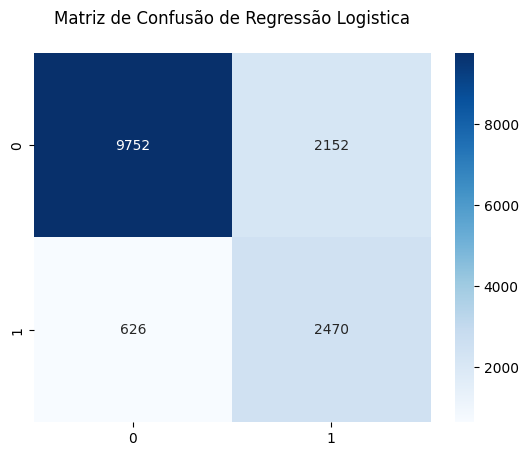

In [ ]:
# Definir hiperparâmetros de tunagem
param_grid_reglog = [
    # 1. Penalidade L2 (Ridge) - O padrão e mais versátil
    # Ótimo para evitar overfitting reduzindo os coeficientes de forma suave.
    {
        'penalty': ['l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100], 
        'solver': ['lbfgs', 'newton-cg', 'sag'],
        'max_iter': [1000, 2500] 
    },
    
    # 2. Penalidade L1 (Lasso) - Faz seleção de variáveis
    # Excelente se você tem muitas colunas e quer que o modelo "zere" as menos importantes.
    {
        'penalty': ['l1'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'saga'],
        'max_iter': [1000, 2500]
    },
    
    # 3. Penalidade ElasticNet - O melhor dos dois mundos (L1 + L2)
    # Exclusivo do solver 'saga'. Mistura seleção de variáveis com redução suave.
    {
        'penalty': ['elasticnet'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['saga'],
        'l1_ratio': [0.2, 0.5, 0.8], # 0.2 age mais como L2, 0.8 age mais como L1
        'max_iter': [2500, 4000]     # 'saga' com elasticnet demora mais para convergir
    },
    
    # 4. Sem penalidade (Regressão Logística Clássica)
    # Sem regularização matemática. Depende puramente dos dados originais.
    {
        'penalty': [None],
        'solver': ['lbfgs', 'newton-cg'],
        'max_iter': [1000, 2500]
    }
]

caminho_modelo = 'modelo_reg_log.pkl'
best_reg_log = tunagem(caminho_modelo, "Regressão Logistica", reg_log, X_transformado, y_treino, param_grid_reglog)

## SVC

### O Modelo Support Vector Machine (SVM / SVC)

O **Support Vector Machine (SVM)**, ou Máquina de Vetores de Suporte, é um dos algoritmos mais robustos e poderosos do aprendizado de máquina. Como estamos lidando com um problema de categorização (Churn vs. Não Churn), utilizamos a sua variante de classificação, chamada de **SVC** (*Support Vector Classifier*).

A intuição central do SVM é encontrar a **fronteira de decisão ideal** que separe as classes com a maior margem de segurança possível.

**Como o algoritmo funciona?**
A lógica do SVM é fortemente baseada em geometria. Imagine que cada cliente do nosso banco de dados é um ponto em um espaço multidimensional (onde cada dimensão é uma variável):
1. **O Hiperplano:** O modelo tenta traçar uma "parede" (chamada matematicamente de hiperplano) que divida perfeitamente os clientes que cancelaram dos que permaneceram ativos.
2. **A Margem Máxima:** Diferente de outros algoritmos que traçam qualquer linha que separe os dados, o SVM é rigoroso: ele busca o hiperplano que mantenha a **maior distância possível** (a maior margem) até os pontos mais próximos de ambas as classes.
3. **Vetores de Suporte:** Os poucos clientes que ficam exatamente no limite dessa margem são chamados de *Vetores de Suporte*. O SVM é fascinante porque ele praticamente ignora os clientes "óbvios" (que estão longe da fronteira) e foca todo o seu cálculo nesses casos críticos e difíceis de separar.

**O Poder do "Kernel Trick" (Truque do Kernel)**
Na vida real, é muito raro conseguir separar clientes propensos ao *churn* com uma linha reta ou um plano reto (os dados são não-lineares). O grande trunfo do SVM é o uso de funções matemáticas chamadas *Kernels* (como o RBF ou Polinomial). Essas funções projetam nossos dados originais em um espaço de dimensões muito mais altas, onde uma separação linear se torna possível, resolvendo problemas de altíssima complexidade.

### 📊 Treino e Avaliação do Modelo


In [ ]:
# Instanciar modelo de acordo com o desbalanceamento de classe
svc = SVC( class_weight= 'balanced' )

Acurácia média : 0.848, Intervalo de Confiança: [0.832,0.865]

Relatório de métricas de SVC:

              precision    recall  f1-score   support

           0       0.96      0.85      0.90     11904
           1       0.59      0.85      0.70      3096

    accuracy                           0.85     15000
   macro avg       0.77      0.85      0.80     15000
weighted avg       0.88      0.85      0.86     15000



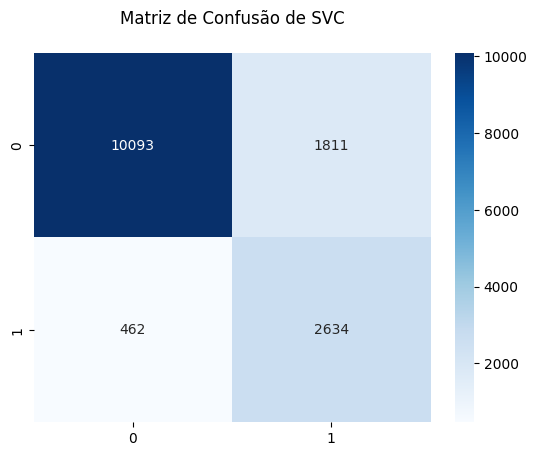

In [ ]:
# Avaliar perfomace do modelo base
avaliacao_perfomace( "SVC", svc, X_transformado, y_treino )

### ⚙️ Seleção de Hiper-parâmetros

A busca pelo hiperplano ideal no modelo SVC depende muito do tipo de *Kernel* escolhido. Como cada *Kernel* possui parâmetros matemáticos exclusivos, dividimos nosso Grid Search em três blocos focados, otimizando o tempo de processamento e evitando cruzamentos inválidos.

Abaixo, detalhamos a função de cada bloco testado:

#### 1. Primeiro Grid: Kernel RBF (Radial Basis Function)
O RBF é o *kernel* padrão e geralmente o mais poderoso. Ele lida excepcionalmente bem com dados onde a fronteira de separação entre clientes propensos a *churn* e clientes retidos tem um formato circular ou altamente complexo/não-linear.
* **`kernel` ['rbf']:** Define o uso da Função de Base Radial.
* **`C` [0.01, 0.1, 1, 10, 100]:** É o parâmetro de Regularização (penalidade por erro). 
    * Um **C baixo (ex: 0.01)** cria uma margem de decisão mais "suave", permitindo que alguns clientes sejam classificados incorretamente no treino em troca de um modelo que generalize melhor (evita *overfitting*). 
    * Um **C alto (ex: 100)** cria uma margem rígida, forçando o modelo a classificar corretamente o máximo possível de pontos de treino (o que pode gerar *overfitting*).
* **`gamma` [0.1, ..., 0.0001, 'scale']:** Define o "raio de influência" de um único cliente (Vetor de Suporte). Valores muito baixos significam que a influência vai longe (fronteira mais reta/suave). Valores altos significam que a influência é curta (a fronteira fica cheia de curvas contornando clientes específicos). A opção `scale` é um cálculo automático inteligente baseado na variância dos nossos dados.

#### 2. Segundo Grid: Kernel Linear
Este bloco serve para testar a hipótese mais simples: e se os nossos dados puderem ser separados apenas com uma linha reta (ou plano reto)? 
* **`kernel` ['linear']:** Como não há curvas matemáticas ou projeções de dimensão envolvidas, parâmetros como `gamma` ou `degree` não existem aqui.
* **`C` [0.01, 0.1, 1, 10]:** Mantemos o teste de rigidez da margem. Se o problema for de fato linearmente separável, este *kernel* será infinitamente mais rápido de treinar do que o RBF.

#### 3. Terceiro Grid: Kernel Polinomial
O *kernel* polinomial eleva as variáveis originais a potências matemáticas, ajudando a encontrar fronteiras curvas, mas de uma forma estruturalmente diferente do RBF.
* **`kernel` ['poly']:** Define o uso de polinômios.
* **`degree` [2, 3]:** É o grau do polinômio. Testamos elevar as características dos clientes ao quadrado (2) e ao cubo (3). Não usamos graus maiores para evitar um custo computacional explosivo e o risco de *overfitting*.
* **`gamma` ['scale']:** Mantemos o cálculo automático de escala para facilitar a convergência.
* **`coef0` [0.0, 1.0]:** É o "termo independente" na fórmula do polinômio. Ele atua regulando o quanto o modelo deve ser influenciado pelos termos de grau alto (como as variáveis ao cubo) em relação aos de grau baixo.

Modelo não encontrado. Iniciando GRID SEARCH (41 combinações)
Fitting 5 folds for each of 41 candidates, totalling 205 fits
Busca Finalizada!

Melhores parâmetros encontrados:
{'C': 1, 'coef0': 1.0, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}

Performance Média do Melhor estimador:

Acurácia média : 0.838, Intervalo de Confiança: [0.825,0.852]

Relatório de métricas de SVC:

              precision    recall  f1-score   support

           0       0.96      0.83      0.89     11904
           1       0.57      0.85      0.69      3096

    accuracy                           0.84     15000
   macro avg       0.76      0.84      0.79     15000
weighted avg       0.88      0.84      0.85     15000



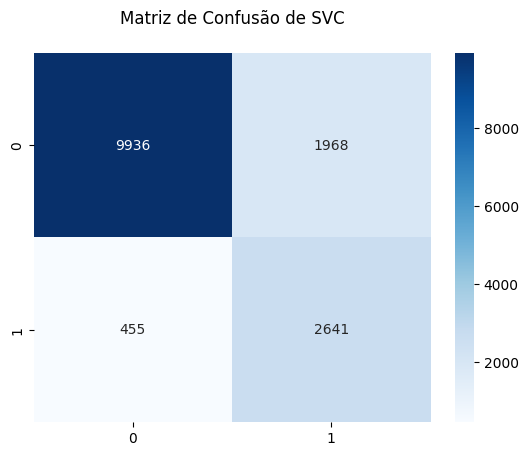

In [46]:
# Executar a tunagem
param_grid = [
    # Busca para Kernel RBF
    {
        'C': [0.01, 0.1, 1, 10, 100],
        'gamma': [0.1, 0.01, 0.001, 0.0001, 'scale'],
        'kernel': ['rbf']
    },
    # Busca para Kernel Linear
    {
        'C': [0.01, 0.1, 1, 10],
        'kernel': ['linear']
    },
    # Busca para Kernel Polinomial
    {
        'C': [0.1, 1, 10],
        'kernel': ['poly'],
        'degree': [2, 3],
        'gamma': ['scale'],
        'coef0': [0.0, 1.0]
    }
]

caminho_modelo = 'modelo_svc.pkl'
best_svc = tunagem(caminho_modelo, "SVC", svc, X_transformado, y_treino, param_grid)

## Random Forest

O **Random Forest** é um dos algoritmos de *Ensemble* (conjunto) mais populares, robustos e versáteis do Machine Learning. Como o próprio nome sugere, ele funciona criando uma verdadeira "floresta" composta por dezenas ou centenas de **Árvores de Decisão**.

A filosofia por trás deste algoritmo é a "sabedoria da multidão": em vez de confiar na previsão de um único modelo isolado (que pode cometer erros ou criar vieses), o Random Forest combina a opinião de várias árvores para decidir com maior precisão se um cliente vai dar *Churn* ou permanecer ativo.

**Como o algoritmo funciona?**
O segredo do Random Forest está na introdução de aleatoriedade para criar árvores diversificadas. Ele faz isso em duas frentes:
1. **Amostragem de Dados (*Bagging*):** O algoritmo cria vários miniconjuntos de dados a partir da nossa base de treinamento original, sorteando clientes aleatoriamente (permitindo repetições). Cada árvore da floresta é treinada usando apenas um desses recortes.
2. **Aleatoriedade de Variáveis:** Na hora de criar um nó de decisão (por exemplo, decidir se divide os clientes pelo "Saldo" ou pela "Idade"), cada árvore não olha para todas as colunas disponíveis. Ela é forçada a escolher a melhor divisão a partir de um subconjunto aleatório de variáveis.
3. **A Votação:** Quando apresentamos um novo cliente ao modelo pronto, os dados desse cliente passam por todas as árvores. Cada árvore dá o seu voto (1 para Churn, 0 para Não Churn). A previsão final do Random Forest é simplesmente a classe que receber a **maioria dos votos**.


### 📊 Treino e Avaliação do Modelo


In [23]:
# Instanciar modelo
rf = RandomForestClassifier( random_state= 42, class_weight= 'balanced')

Acurácia média : 0.89, Intervalo de Confiança: [0.885,0.896]

Relatório de métricas de Random Forest:

              precision    recall  f1-score   support

           0       0.91      0.96      0.93     11904
           1       0.79      0.64      0.71      3096

    accuracy                           0.89     15000
   macro avg       0.85      0.80      0.82     15000
weighted avg       0.89      0.89      0.89     15000



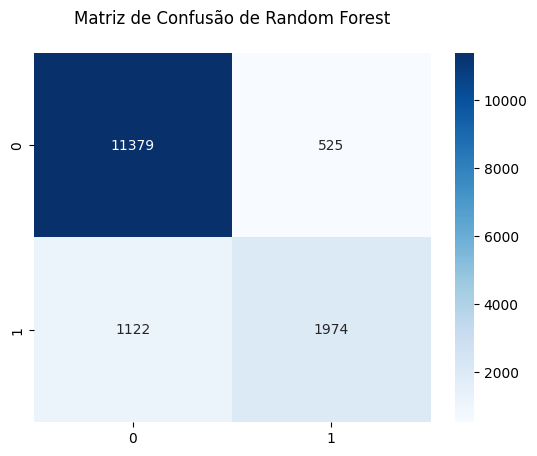

In [24]:
# Avaliar modelo base
avaliacao_perfomace( "Random Forest", rf, X_transformado, y_treino )

### ⚙️ Seleção de Hiper-parâmetros

Diferente do SVC ou da Regressão Logística, o Random Forest não utiliza cálculos matemáticos de distância ou regularização algébrica. Em vez disso, seus hiperparâmetros controlam a **arquitetura das árvores de decisão** (seu tamanho e regras de divisão) e o **tamanho da floresta**. 

Como todas essas configurações são compatíveis entre si, podemos colocar tudo em um único dicionário para o nosso Grid Search. Abaixo, detalhamos a função de cada hiperparâmetro testado:

* **`n_estimators` [50, 100, 200]:** Define a quantidade de "árvores" na nossa floresta. 
    * Um número maior (como 200) geralmente aumenta a estabilidade e a precisão do modelo (pois temos mais "votos"), mas deixa o treinamento e a previsão mais lentos. Testamos desde uma floresta menor (50) até uma mais robusta (200) para encontrar o ponto de equilíbrio entre performance e custo computacional.
* **`max_depth` [None, 10, 20]:** Controla a profundidade máxima (nível de ramificação) de cada árvore individual.
    * `None`: As árvores crescem livremente até que consigam separar perfeitamente os clientes que deram *churn* dos que não deram. Isso tem um altíssimo risco de *overfitting* (decorar os dados de treino).
    * `10` e `20`: Forçamos as árvores a pararem de crescer mais cedo. Isso cria árvores mais "genéricas", ajudando o modelo a focar nos padrões principais e não nas exceções isoladas.
* **`min_samples_split` [2, 5]:** Define o número mínimo de clientes necessários em um nó para que a árvore decida criar uma nova divisão (ramificação).
    * `2`: É o padrão. A árvore pode se dividir até separar os clientes de dois em dois.
    * `5`: Exige um grupo mínimo de 5 clientes para tentar criar uma regra nova. Isso evita que o modelo crie regras complexas para grupos muito pequenos, combatendo o *overfitting*.
* **`min_samples_leaf` [1, 2]:** Define o número mínimo de clientes que devem sobrar na "folha" final da árvore (o ponto onde ela toma a decisão final). 
    * Exigir pelo menos `2` clientes em uma folha impede que a árvore isole um único cliente com características bizarras como se fosse um padrão confiável.
* **`criterion` ['gini', 'entropy']:** É a métrica matemática usada para escolher qual é a melhor variável para dividir os dados.
    * `gini` (Impureza de Gini): Tenta minimizar a probabilidade de um cliente ser classificado incorretamente. Costuma ser um pouco mais rápido de calcular.
    * `entropy` (Ganho de Informação): Baseado na teoria da informação, tenta maximizar a redução do "caos" ou incerteza após uma divisão. 


Modelo não encontrado. Iniciando GRID SEARCH (72 combinações)
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Busca Finalizada!

Melhores parâmetros encontrados:
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Performance Média do Melhor estimador:

Acurácia média : 0.876, Intervalo de Confiança: [0.867,0.886]

Relatório de métricas de Random Forest:

              precision    recall  f1-score   support

           0       0.94      0.90      0.92     11904
           1       0.67      0.79      0.73      3096

    accuracy                           0.88     15000
   macro avg       0.81      0.84      0.82     15000
weighted avg       0.89      0.88      0.88     15000



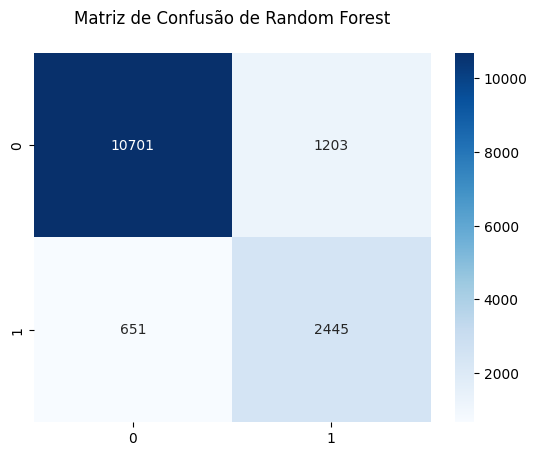

In [47]:
# Executar Tunagem
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'criterion': ['gini', 'entropy']
}

caminho_modelo = 'modelo_rf.pkl'
best_rf = tunagem(caminho_modelo, "Random Forest", rf, X_transformado, y_treino, param_grid_rf)

### 📊 Comparação de Modelos e Seleção do Estimador Final

Após a fase de tunagem de hiperparâmetros para cada um dos quatro algoritmos, consolidamos as métricas para determinar qual modelo melhor atende à nossa necessidade de negócio: a retenção proativa de clientes.

| Modelo | Acurácia Média | Recall (Classe 1 - *Churn*) |
| :--- | :---: | :---: |
| Random Forest | **0.890** | 0.64 |
| **SVC (SVM)** | 0.838 | **0.85** |
| Regressão Logística | 0.815 | 0.80 |
| KNN | 0.883 | 0.60 |

---

#### ⚖️ Por que o SVC foi selecionado como o melhor modelo?

Embora o *Random Forest* e o *KNN* tenham apresentado métricas de Acurácia superiores, a escolha do modelo vencedor para um problema de **Churn Bancário** deve ser pautada pelo impacto financeiro e estratégico das previsões.

1.  **Priorização do Recall sobre a Acurácia:** Em problemas de evasão, nosso maior risco é o **Falso Negativo** (quando o modelo prevê que o cliente permanecerá, mas ele efetivamente cancela a conta). O custo de perder um cliente é muito maior do que o custo de uma campanha de marketing ou um benefício oferecido a um cliente que não pretendia sair.
2.  **Minimização de Falsos Negativos:** O **SVC apresentou o maior Recall (0.85)** para a classe de interesse (*Exited* = 1). Isso significa que ele é capaz de identificar corretamente 85% dos clientes que estão prestes a sair da instituição. Em comparação, o Random Forest identificaria apenas 64%, deixando passar despercebidos 36% dos clientes em risco.
3.  **Equilíbrio Estratégico:** Mesmo com uma acurácia global ligeiramente menor (83.8%), o SVC garante que a equipe de retenção tenha em mãos a lista mais completa possível de clientes vulneráveis.

**Conclusão:** O modelo **SVC (Support Vector Classifier)** é o escolhido para produção, pois maximiza a nossa capacidade de intervenção preventiva, reduzindo drasticamente a taxa de clientes que deixariam o banco sem que tivéssemos a chance de retê-los.

## 🔍 Validação da Análise de Dados (EDA) via Feature Importance

Embora o **Random Forest** não tenha sido selecionado como o nosso modelo de produção (devido ao foco na maximização do *recall* atendido pelo SVC), ele permanece como uma ferramenta de diagnóstico indispensável. Uma das grandes vantagens das florestas aleatórias é a sua capacidade nativa de mensurar a importância de cada variável para a tomada de decisão.

Utilizaremos o estimador tunado para extrair e visualizar o **Feature Importance**. O objetivo desta etapa é realizar uma "prova real" estatística: verificaremos se os atributos que o modelo considerou mais relevantes para prever o *churn* coincidem com os padrões e correlações observados durante a nossa **Análise Exploratória de Dados** inicial. 

In [ ]:
# Método na etapa de pré processamento que retorna nome das features
pipeline.get_feature_names_out()

array(['col_num__CreditScore', 'col_num__Age', 'col_num__Tenure',
       'col_num__Balance', 'col_num__NumOfProducts', 'col_num__HasCrCard',
       'col_num__IsActiveMember', 'col_num__EstimatedSalary',
       'col_num__balance_salary_ratio', 'col_num__tenure_age_ratio',
       'col_num__credit_age_ratio', 'col_num__active_product_score',
       'col_num__balance_per_product', 'col_cat__Geography_France',
       'col_cat__Geography_Germany', 'col_cat__Geography_Spain',
       'col_cat__Gender_Female', 'col_cat__Gender_Male'], dtype=object)

In [ ]:
# Criar Transformador para extrair top features
def indices_of_top_k(arr, k):
    return np.sort(np.argpartition(np.array(arr), -k)[-k:])

class TopFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, feature_importances, k):
        self.feature_importances = feature_importances
        self.k = k
    def fit(self, X, y=None):
        self.feature_indices_ = indices_of_top_k(self.feature_importances, self.k)
        return self
    def transform(self, X):
        return X[:, self.feature_indices_]

In [62]:
# Guardar features mais importantes e seus respectivos nomes
feature_importances = best_rf.feature_importances_
feature_names = pipeline.get_feature_names_out()

In [106]:
# Vamos avaliar os indices dos features mais importantes
k = 10
top_k_feature_indices = indices_of_top_k(feature_importances, k)
top_k_feature_indices

array([ 1,  3,  4,  6, 10, 11, 12, 14, 16, 17])

In [113]:
# Vamos avaliar os nomes dos features mais importantes

top_features = np.array(feature_names)[top_k_feature_indices]
top_features

array(['col_num__Age', 'col_num__Balance', 'col_num__NumOfProducts',
       'col_num__IsActiveMember', 'col_num__credit_age_ratio',
       'col_num__active_product_score', 'col_num__balance_per_product',
       'col_cat__Geography_Germany', 'col_cat__Gender_Female',
       'col_cat__Gender_Male'], dtype=object)

In [114]:
# Extrair os valores de importância das top features
top_importances = feature_importances[top_k_feature_indices]

# Criar um DataFrame para facilitar a plotagem com Seaborn
df_importances = pd.DataFrame({
    'Feature': top_features,
    'Importância': top_importances
}).sort_values(by='Importância', ascending=False)


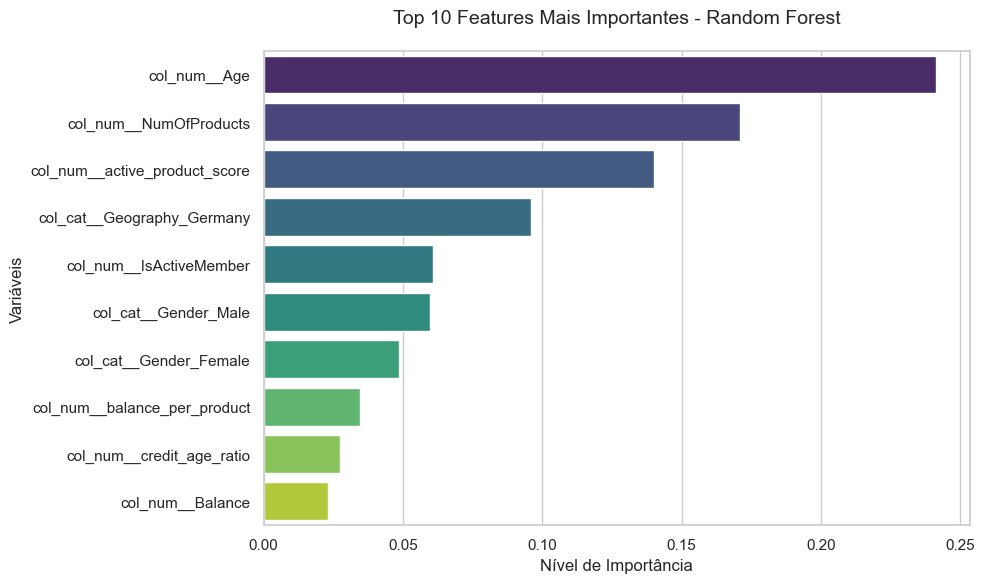

In [115]:
#  Configurar o estilo para criar o gráfico
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_importances,
    x='Importância',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)

# Acréscimo de infos no gráfico
plt.title(f'Top {k} Features Mais Importantes - Random Forest', fontsize=14, pad=20)
plt.xlabel('Nível de Importância', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.tight_layout()

plt.show()